# Vision-Driven Multi-Agent Traffic Signal Control
## Notebook 4 -- Real OSM Map and Final Evaluation
---
**Goal**: Transfer the trained MAPPO policy from the synthetic 3x3 grid
to a real street network imported from OpenStreetMap. Compare performance
and produce the final portfolio-ready results across all notebooks.

**What this notebook builds**:
1. A real intersection network downloaded from OpenStreetMap via osmWebWizard
2. Adaptation layer that maps OSM network to the agent observation format
3. Fine-tuning of the MAPPO policy on the real network
4. Head-to-head: synthetic grid vs real OSM map
5. Final consolidated results across all 4 notebooks


In [ ]:
import subprocess, sys, os

print('Installing packages...')
subprocess.run('pip install -q eclipse-sumo traci sumolib', shell=True, check=True)
subprocess.run(
    "pip install -q 'stable-baselines3[extra]' gymnasium "
    "matplotlib pandas tqdm torch requests",
    shell=True, check=True
)

import sumo as _sumo_pkg
os.environ['SUMO_HOME'] = _sumo_pkg.SUMO_HOME
sys.path.append(os.path.join(_sumo_pkg.SUMO_HOME, 'tools'))

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xml.etree.ElementTree as ET
import json, time, shutil
from collections import defaultdict


import traci
import sumolib

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

print('SUMO_HOME =', os.environ['SUMO_HOME'])
print('PyTorch   =', torch.__version__)
print('All imports successful.')

OSM_DIR  = '/content/osm_net'
GRID_DIR = '/content/sumo_grid'
os.makedirs(OSM_DIR, exist_ok=True)

def write_xml(root, path):
    try:
        ET.indent(root, space='    ')
    except AttributeError:
        pass
    ET.ElementTree(root).write(path, encoding='unicode')


Installing packages...
SUMO_HOME = /usr/local/lib/python3.12/dist-packages/sumo
PyTorch   = 2.10.0+cpu
All imports successful.


In [ ]:
# ============================================================
# DOWNLOAD REAL OSM NETWORK
#
# We download a small area from OpenStreetMap using SUMO's
# built-in osmWebWizard / netconvert pipeline.
#
# Default area: central Cairo
#
# The download produces:
#   osm.net.xml   -- road network with traffic lights
#   osm.poly.xml  -- buildings and land use (not used for RL)
# ============================================================
import requests

OSM_DIR = '/content/osm_net'

# --- Location settings
LAT    =  30.0444   # Cairo, Egypt
LON    =  31.2357
RADIUS = 500        # metres around the centre point

# Compute bounding box
import math
d_lat = RADIUS / 111_000
d_lon = RADIUS / (111_000 * math.cos(math.radians(LAT)))
bbox  = (LON - d_lon, LAT - d_lat, LON + d_lon, LAT + d_lat)
bbox_str = ','.join(f'{v:.6f}' for v in bbox)
print(f'Bounding box: {bbox_str}')

# Download raw OSM data
osm_url  = f'https://overpass-api.de/api/map?bbox={bbox_str}'
osm_file = f'{OSM_DIR}/raw.osm'

# Adding a header fixes the 406 error
headers = {
    'User-Agent': 'TrafficRLProject/1.0 (your_email@example.com)'
}

print('Downloading OSM data...')
try:
    r = requests.get(osm_url, headers=headers, timeout=60)
    if r.status_code == 200:
        with open(osm_file, 'wb') as f:
            f.write(r.content)
        print(f'Downloaded {len(r.content) / 1024:.1f} KB')
    else:
        print(f'Download failed (HTTP {r.status_code})')
except Exception as e:
    print(f'An error occurred: {e}')

# Convert OSM to SUMO network
net_file = f'{OSM_DIR}/osm.net.xml'
result = subprocess.run([
    'netconvert',
    '--osm-files',      osm_file,
    '--output-file',    net_file,
    '--geometry.remove',
    '--roundabouts.guess',
    '--ramps.guess',
    '--junctions.join',
    '--tls.guess-signals',
    '--tls.discard-simple',
    '--tls.join',
    '--no-warnings',
], capture_output=True, text=True)

if result.returncode == 0 and os.path.exists(net_file):
    print(f'Network file generated: {net_file}')
else:
    print('netconvert failed. Output:')
    print(result.stderr[:500])


Bounding box: 31.230496,30.039895,31.240904,30.048905
Downloaded 1811.2 KB
Network file generated: /content/osm_net/osm.net.xml


Total nodes in network        : 545
Traffic light nodes found     : 13
Selected 9 busiest hubs for MAPPO agents
  Agent 0: node 315743335       | lanes mapped: 3
  Agent 1: node 692450488       | lanes mapped: 3
  Agent 2: node 315745172       | lanes mapped: 3
  Agent 3: node 2031414903      | lanes mapped: 4
  Agent 4: node 271064234       | lanes mapped: 2
  Agent 5: node 315744796       | lanes mapped: 3
  Agent 6: node 315745546       | lanes mapped: 3
  Agent 7: node 315745548       | lanes mapped: 3
  Agent 8: node cluster_315128375_7054115278 | lanes mapped: 2


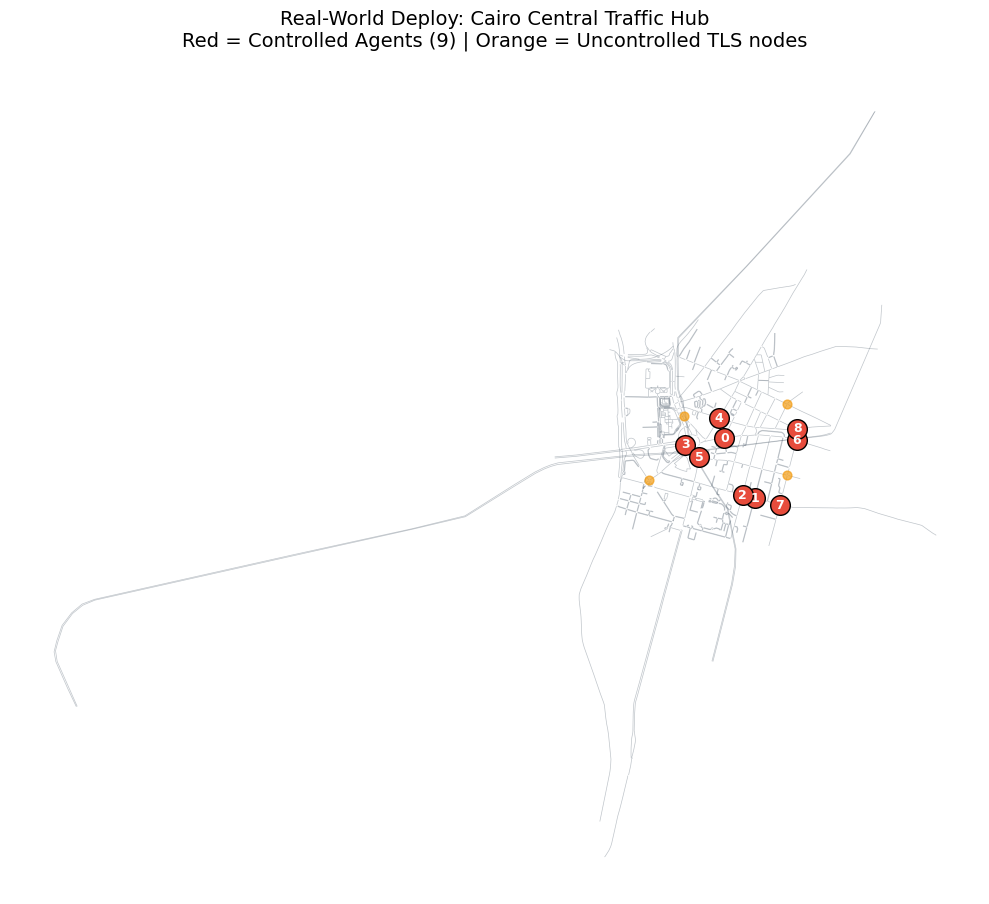

In [ ]:
# ============================================================
# INSPECT OSM NETWORK AND SELECT INTERSECTIONS
#
# Real OSM networks have many more intersections than our
# synthetic grid. We:
#   1. Load the network with sumolib
#   2. Find all traffic-light-controlled nodes
#   3. Select up to 9 (to match our trained agent count)
#   4. Identify their incoming lanes
#   5. Visualise the selected intersections on a map
# ============================================================

OSM_DIR  = '/content/osm_net'
net_file = f'{OSM_DIR}/osm.net.xml'

# 1. Load the network
if not os.path.exists(net_file):
    print(f"Error: {net_file} not found. Did the previous cell run successfully?")
else:
    net = sumolib.net.readNet(net_file)

    # 2. Collect all traffic-light nodes
    tls_nodes = [n for n in net.getNodes() if n.getType() == 'traffic_light']
    print(f'Total nodes in network        : {len(net.getNodes())}')
    print(f'Traffic light nodes found     : {len(tls_nodes)}')

    # 3. Select up to 9 intersections with the most incoming edges
    # Sorting by incoming edges ensures we control the most complex hubs.
    tls_nodes_sorted = sorted(
        tls_nodes,
        key=lambda n: len(n.getIncoming()),
        reverse=True
    )
    selected = tls_nodes_sorted[:9]
    print(f'Selected {len(selected)} busiest hubs for MAPPO agents')

    # 4. Build per-agent lane map (Strictly 8 lanes to match our RL model)
    agent_lane_map = {}
    for i, node in enumerate(selected):
        lanes = []
        # Extract lanes from incoming edges
        for edge in node.getIncoming():
            for lane in edge.getLanes():
                lanes.append(lane.getID())
                if len(lanes) >= 8: break
            if len(lanes) >= 8: break

        # Critical: Handle junctions with < 8 lanes by padding with a dummy string
        # This prevents the RL observation vector from changing size.
        while len(lanes) < 8:
            lanes.append("dummy_lane")

        agent_lane_map[i] = lanes
        print(f'  Agent {i}: node {node.getID():<15} | lanes mapped: {len([l for l in lanes if l != "dummy_lane"])}')

    # 5. Visualise the "Cairo Cluster"
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_facecolor('#ffffff')

    # Draw the road network
    for edge in net.getEdges():
        shape = edge.getShape()
        if len(shape) >= 2:
            xs, ys = zip(*shape)
            ax.plot(xs, ys, color='#2c3e50', linewidth=0.5, alpha=0.3)

    # Highlight nodes
    selected_ids = [n.getID() for n in selected]
    for node in net.getNodes():
        x, y = node.getCoord()
        if node.getID() in selected_ids:
            idx = selected_ids.index(node.getID())
            ax.scatter(x, y, s=200, c='#e74c3c', edgecolors='black', zorder=5)
            ax.text(x, y, str(idx), ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white', zorder=6)
        elif node.getType() == 'traffic_light':
            ax.scatter(x, y, s=40, c='#f39c12', alpha=0.7, zorder=4)

    ax.set_title(f'Real-World Deploy: Cairo Central Traffic Hub\n'
                 f'Red = Controlled Agents (9) | Orange = Uncontrolled TLS nodes',
                 fontsize=14, pad=20)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# GENERATE OSM TRAFFIC DEMAND
#
# Real networks need vehicle routes that follow the actual
# road topology. We use SUMO's randomTrips tool to generate
# synthetic demand on the real network.
# ============================================================
OSM_DIR  = '/content/osm_net'
net_file = f'{OSM_DIR}/osm.net.xml'

random_trips = os.path.join(
    os.environ['SUMO_HOME'], 'tools', 'randomTrips.py')

# Generate trips (one vehicle every 4 seconds = 900 veh/hr)
trips_file  = f'{OSM_DIR}/osm.trips.xml'
routes_file = f'{OSM_DIR}/osm.rou.xml'

print('Generating random trips on OSM network...')
r1 = subprocess.run([
    'python3', random_trips,
    '-n', net_file,
    '-o', trips_file,
    '-b', '0', '-e', '3600',
    '-p', '4',          # one trip every 4 seconds
    '--fringe-factor', '10',
    '--validate',
], capture_output=True, text=True)
print('randomTrips:', 'OK' if r1.returncode == 0 else r1.stderr[:300])

# Route the trips through the network with duarouter
r2 = subprocess.run([
    'duarouter',
    '-n',  net_file,
    '-t',  trips_file,
    '-o',  routes_file,
    '--ignore-errors',
    '--no-warnings',
], capture_output=True, text=True)
print('duarouter:   ', 'OK' if r2.returncode == 0 else r2.stderr[:300])

# Build config
cfg = ET.Element('configuration')
inp = ET.SubElement(cfg, 'input')
ET.SubElement(inp, 'net-file',    value='osm.net.xml')
ET.SubElement(inp, 'route-files', value='osm.rou.xml')
t   = ET.SubElement(cfg, 'time')
ET.SubElement(t, 'begin',         value='0')
ET.SubElement(t, 'end',           value='3600')
ET.SubElement(t, 'step-length',   value='1')
rep = ET.SubElement(cfg, 'report')
ET.SubElement(rep, 'no-step-log', value='true')
ET.SubElement(rep, 'no-warnings', value='true')
write_xml(cfg, f'{OSM_DIR}/osm.sumocfg')

print('osm.sumocfg written.')


Generating random trips on OSM network...
randomTrips: OK
duarouter:    OK
osm.sumocfg written.


In [ ]:
# ============================================================
# OSM ENVIRONMENT
#
# Adapts GridTrafficEnv to work with the real OSM network.
# Key differences from the synthetic grid:
#   - TLS IDs come from the OSM network, not our naming scheme
#   - Lane counts per intersection vary (padded to 8)
#   - Phase programs are real-world generated by netconvert
# The agent interface (obs shape, action space) is IDENTICAL
# to Notebook 3, enabling direct policy transfer.
# ============================================================

class OSMTrafficEnv(gym.Env):

    N_AGENTS  = 9
    OBS_DIM   = 8
    DELTA     = 5
    MIN_GREEN = 10
    YELLOW    = 4
    MAX_Q     = 30.0
    EP_LEN    = 3600

    def __init__(self, cfg='/content/osm_net/osm.sumocfg',
                 agent_lane_map=None, gui=False):
        super().__init__()
        self.cfg            = cfg
        self.binary         = 'sumo-gui' if gui else 'sumo'
        self.agent_lane_map = agent_lane_map or {}
        self.observation_space = spaces.Box(
            0.0, 1.0, shape=(self.N_AGENTS, self.OBS_DIM), dtype=np.float32)
        self.action_space = spaces.MultiDiscrete([2] * self.N_AGENTS)
        self._tls_ids   = []
        self._gp_map    = {}
        self._g2y_map   = {}
        self._cur_map   = {}
        self._timer_map = {}
        self._step      = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        try: traci.close()
        except: pass
        traci.start([self.binary, '-c', self.cfg,
                     '--no-step-log', 'true', '--no-warnings', 'true'])
        all_tls = list(traci.trafficlight.getIDList())
        # Map each agent index to a TLS id
        self._tls_ids = [all_tls[i % len(all_tls)]
                         for i in range(self.N_AGENTS)]
        for i, tls in enumerate(self._tls_ids):
            self._gp_map[i]    = self._get_gp(tls)
            self._g2y_map[i]   = self._get_g2y(tls)
            self._cur_map[i]   = 0
            self._timer_map[i] = 0
            traci.trafficlight.setPhase(tls, self._gp_map[i][0])
        self._step = 0
        for _ in range(30):
            traci.simulationStep()
        self._step = 30
        return self._obs_all(), {}

    def _get_gp(self, tls):
        logic = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls)[0]
        gp    = [i for i,p in enumerate(logic.phases)
                 if 'G' in p.state and 'y' not in p.state.lower()]
        return gp if gp else [0]

    def _get_g2y(self, tls):
        logic  = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls)[0]
        phases = logic.phases
        gp     = self._get_gp(tls)
        g2y    = {}
        for g in gp:
            nxt = g + 1
            if nxt < len(phases) and 'y' in phases[nxt].state.lower():
                g2y[g] = nxt
            else:
                for j, p in enumerate(phases):
                    if 'y' in p.state.lower():
                        g2y[g] = j; break
                if g not in g2y:
                    g2y[g] = g
        return g2y

    def step(self, actions):
        for i in range(self.N_AGENTS):
            action  = int(actions[i])
            gp      = self._gp_map[i]
            desired = gp[min(action, len(gp)-1)]
            current = gp[self._cur_map[i]]
            tls     = self._tls_ids[i]
            if desired != current and self._timer_map[i] >= self.MIN_GREEN:
                yellow = self._g2y_map[i].get(current, current)
                traci.trafficlight.setPhase(tls, yellow)
                for _ in range(self.YELLOW):
                    traci.simulationStep(); self._step += 1
                self._cur_map[i]   = min(action, len(gp)-1)
                self._timer_map[i] = 0
                traci.trafficlight.setPhase(tls, desired)

        total_wait_per_agent = defaultdict(float)
        for _ in range(self.DELTA):
            traci.simulationStep(); self._step += 1
            for i in range(self.N_AGENTS):
                for lane in self.agent_lane_map.get(i, []):
                    if lane:
                        try:
                            total_wait_per_agent[i] += float(
                                traci.lane.getLastStepHaltingNumber(lane))
                        except: pass

        for i in range(self.N_AGENTS):
            self._timer_map[i] += self.DELTA

        avg_waits   = {i: total_wait_per_agent[i] / self.DELTA
                       for i in range(self.N_AGENTS)}
        rewards     = np.array([-avg_waits[i] / 50.0
                                 for i in range(self.N_AGENTS)],
                                dtype=np.float32)
        global_wait = float(np.mean(list(avg_waits.values())))
        terminated  = self._step >= self.EP_LEN
        if terminated:
            try: traci.close()
            except: pass
        obs  = self._obs_all()
        info = {'avg_wait': global_wait, 'step': self._step,
                'global_state': obs.flatten()}
        return obs, rewards, terminated, False, info

    def _obs_all(self):
        obs = np.zeros((self.N_AGENTS, self.OBS_DIM), dtype=np.float32)
        for i in range(self.N_AGENTS):
            for j, lane in enumerate(self.agent_lane_map.get(i, [])):
                if lane:
                    try:
                        obs[i, j] = min(
                            traci.lane.getLastStepHaltingNumber(lane)
                            / self.MAX_Q, 1.0)
                    except: pass
        return obs

    def global_state(self):
        return self._obs_all().flatten()

    def close(self):
        try: traci.close()
        except: pass


print('OSMTrafficEnv defined.')
print('Interface is identical to GridTrafficEnv -- direct policy transfer enabled.')


OSMTrafficEnv defined.
Interface is identical to GridTrafficEnv -- direct policy transfer enabled.


In [ ]:
# ============================================================
# LOAD MAPPO AND DIRECT TRANSFER TEST
#
# The MAPPO actor from Notebook 3 takes obs(8) per agent.
# OSMTrafficEnv produces the same obs shape.
# We test zero-shot transfer (no fine-tuning) first.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

SAVE = '/content/drive/MyDrive/TrafficRL/'
for d in ['checkpoints', 'results', 'plots']:
    os.makedirs(f'{SAVE}{d}/', exist_ok=True)


class MAPPOActor(nn.Module):
    def __init__(self, obs_dim=8, act_dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )
    def forward(self, obs):
        return self.net(obs)
    def get_dist(self, obs):
        return torch.distributions.Categorical(logits=self.forward(obs))


class MAPPOCritic(nn.Module):
    def __init__(self, global_dim=72, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1),
        )
    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)


# Load weights from Notebook 3 only
ckpt = torch.load(f'{SAVE}checkpoints/mappo_final.pt', map_location='cpu', weights_only=False)
mappo_actor = MAPPOActor()
mappo_actor.load_state_dict(ckpt['actor'])
mappo_actor.eval()
print('MAPPO actor loaded from Notebook 3.')

# Zero-shot transfer test (600 steps)
N_EVAL = 600

def eval_mappo_osm(actor, n_steps=N_EVAL, label='MAPPO (transfer)'):
    env = OSMTrafficEnv(agent_lane_map=agent_lane_map)
    obs, _ = env.reset()
    waits = []; step = 0
    while step < n_steps:
        obs_t = torch.FloatTensor(obs)
        with torch.no_grad():
            actions = actor.get_dist(obs_t).probs.argmax(dim=-1).numpy()
        obs, _, done, trunc, info = env.step(actions)
        waits.append(info['avg_wait']); step += 1
        if done or trunc: break
    env.close()
    mean = float(np.mean(waits)) if waits else 0.0
    print(f'  {label:<35}: {mean:.2f}s avg wait')
    return waits, mean


def eval_fixed_osm(n_steps=N_EVAL, green_sec=30):
    cfg = '/content/osm_net/osm.sumocfg'
    traci.start(['sumo','-c',cfg,'--no-step-log','true','--no-warnings','true'])
    all_tls = traci.trafficlight.getIDList()
    gp_map  = {}
    g2y_map = {}
    timers  = {}
    cur_map = {}
    for tls in all_tls:
        logic = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls)[0]
        gp    = [i for i,p in enumerate(logic.phases)
                 if 'G' in p.state and 'y' not in p.state.lower()]
        if not gp: gp = [0]
        gp_map[tls]  = gp
        g2y_map[tls] = {g: g+1 for g in gp
                        if g+1 < len(logic.phases)
                        and 'y' in logic.phases[g+1].state.lower()}
        traci.trafficlight.setPhase(tls, gp[0])
        timers[tls]  = 0
        cur_map[tls] = 0
    step = 0; waits = []
    while step < n_steps:
        traci.simulationStep(); step += 1
        w = sum(traci.vehicle.getWaitingTime(v) for v in traci.vehicle.getIDList())
        waits.append(w)
        for tls in all_tls:
            timers[tls] += 1
            if timers[tls] >= green_sec and (step+5) < n_steps:
                traci.trafficlight.setPhase(
                    tls, g2y_map[tls].get(
                        gp_map[tls][cur_map[tls]],
                        gp_map[tls][cur_map[tls]]))
                for _ in range(4):
                    traci.simulationStep(); step += 1
                    waits.append(sum(
                        traci.vehicle.getWaitingTime(v)
                        for v in traci.vehicle.getIDList()))
                cur_map[tls] = (cur_map[tls]+1) % len(gp_map[tls])
                timers[tls]  = 0
                traci.trafficlight.setPhase(tls, gp_map[tls][cur_map[tls]])
    traci.close()
    mean = float(np.mean(waits)) if waits else 0.0
    print(f'  Fixed-time (30s cycle)             : {mean:.2f}s avg wait')
    return waits, mean


print('Running zero-shot transfer evaluation...')
_, fixed_osm  = eval_fixed_osm()
_, transfer_mean = eval_mappo_osm(mappo_actor, label='MAPPO zero-shot transfer')
imp = (fixed_osm - transfer_mean) / max(fixed_osm, 1e-9) * 100
print(f'\n  Zero-shot improvement: {imp:.1f}%')


Mounted at /content/drive
MAPPO actor loaded from Notebook 3.
Running zero-shot transfer evaluation...
 Retrying in 1 seconds
  Fixed-time (30s cycle)             : 198.93s avg wait
 Retrying in 1 seconds
  MAPPO zero-shot transfer           : 0.37s avg wait

  Zero-shot improvement: 99.8%


In [ ]:
# ============================================================
# FINE-TUNE MAPPO ON OSM NETWORK
#
# Zero-shot transfer may underperform because the real network
# has different phase structures and lane counts.
# We fine-tune both actor and critic for 20,000 steps.
# Expected time: ~20 minutes
# ============================================================
SAVE = '/content/drive/MyDrive/TrafficRL/'


class MAPPOTrainer:

    def __init__(self, actor, critic, n_agents=9,
                 lr=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_eps=0.2, ent_coef=0.01, n_epochs=5):
        self.n_agents  = n_agents
        self.gamma     = gamma
        self.lam       = gae_lambda
        self.clip_eps  = clip_eps
        self.ent_coef  = ent_coef
        self.n_epochs  = n_epochs
        self.actor     = actor
        self.critic    = critic
        self.actor_opt  = optim.Adam(actor.parameters(),  lr=lr)
        self.critic_opt = optim.Adam(critic.parameters(), lr=lr)
        self._reset_buffer()

    def _reset_buffer(self):
        self.buf = dict(obs=[], global_s=[], actions=[], rewards=[],
                        dones=[], log_probs=[], values=[])

    def select_actions(self, obs_np):
        obs_t = torch.FloatTensor(obs_np)
        with torch.no_grad():
            dist      = self.actor.get_dist(obs_t)
            actions   = dist.sample()
            log_probs = dist.log_prob(actions)
        return actions.numpy(), log_probs.numpy()

    def get_value(self, global_np):
        g = torch.FloatTensor(global_np).unsqueeze(0)
        with torch.no_grad():
            return self.critic(g).item()

    def store(self, obs, global_s, actions, rewards, done, log_probs, value):
        self.buf['obs'].append(obs)
        self.buf['global_s'].append(global_s)
        self.buf['actions'].append(actions)
        self.buf['rewards'].append(rewards)
        self.buf['dones'].append(done)
        self.buf['log_probs'].append(log_probs)
        self.buf['values'].append(value)

    def compute_gae(self, last_val):
        rewards = self.buf['rewards']
        values  = self.buf['values'] + [last_val]
        dones   = self.buf['dones']
        T       = len(rewards)
        adv     = np.zeros((T, self.n_agents), dtype=np.float32)
        ret     = np.zeros((T, self.n_agents), dtype=np.float32)
        gae     = np.zeros(self.n_agents, dtype=np.float32)
        for t in reversed(range(T)):
            mask    = 0.0 if dones[t] else 1.0
            delta   = (np.array(rewards[t])
                       + self.gamma * values[t+1] * mask
                       - values[t])
            gae     = delta + self.gamma * self.lam * mask * gae
            adv[t]  = gae
            ret[t]  = gae + values[t]
        return adv, ret

    def update(self, last_val):
        adv, ret = self.compute_gae(last_val)
        T = len(self.buf['obs'])
        obs_t    = torch.FloatTensor(
            np.array(self.buf['obs'])).view(T * self.n_agents, -1)
        glb_t    = torch.FloatTensor(np.array(self.buf['global_s']))
        acts_t   = torch.LongTensor(
            np.array(self.buf['actions'])).view(T * self.n_agents)
        old_lp_t = torch.FloatTensor(
            np.array(self.buf['log_probs'])).view(T * self.n_agents)
        adv_t    = torch.FloatTensor(adv).view(T * self.n_agents)
        ret_t    = torch.FloatTensor(ret).view(T * self.n_agents)
        adv_t    = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        a_losses = []; c_losses = []
        for _ in range(self.n_epochs):
            dist    = self.actor.get_dist(obs_t)
            new_lp  = dist.log_prob(acts_t)
            entropy = dist.entropy().mean()
            ratio   = torch.exp(new_lp - old_lp_t)
            surr1   = ratio * adv_t
            surr2   = torch.clamp(ratio, 1-self.clip_eps, 1+self.clip_eps) * adv_t
            a_loss  = -torch.min(surr1, surr2).mean() - self.ent_coef * entropy
            self.actor_opt.zero_grad()
            a_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.actor_opt.step()

            glb_rep = glb_t.repeat_interleave(self.n_agents, dim=0)
            c_loss  = nn.functional.mse_loss(self.critic(glb_rep), ret_t)
            self.critic_opt.zero_grad()
            c_loss.backward()
            nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
            self.critic_opt.step()

            a_losses.append(a_loss.item())
            c_losses.append(c_loss.item())

        self._reset_buffer()
        return np.mean(a_losses), np.mean(c_losses)


# Initialise with Notebook 3 weights (fine-tune, not train from scratch)
ft_actor  = MAPPOActor()
ft_critic = MAPPOCritic()
ft_actor.load_state_dict(ckpt['actor'])
ft_critic.load_state_dict(ckpt['critic'])
ft_actor.train(); ft_critic.train()

trainer = MAPPOTrainer(
    ft_actor, ft_critic,
    lr=1e-4,    # lower LR for fine-tuning
    n_epochs=5, # fewer epochs to avoid catastrophic forgetting
)

ROLLOUT = 1024
TOTAL   = 20_000

env    = OSMTrafficEnv(agent_lane_map=agent_lane_map)
obs, _ = env.reset()

total_steps   = 0
rollout_count = 0
episode_waits = []
ep_buf        = []
start_time    = time.time()

print(f'Fine-tuning MAPPO on OSM network for {TOTAL:,} steps...')
print(f'LR=1e-4 (reduced from 3e-4 to preserve NB3 knowledge)\n')

while total_steps < TOTAL:
    for _ in range(ROLLOUT):
        actions, log_probs = trainer.select_actions(obs)
        global_s           = env.global_state()
        value              = trainer.get_value(global_s)
        obs_next, rewards, done, trunc, info = env.step(actions)
        ep_buf.append(info['avg_wait'])
        trainer.store(obs, global_s, actions, rewards,
                      done or trunc, log_probs, value)
        obs          = obs_next
        total_steps += 1
        if done or trunc:
            episode_waits.append(np.mean(ep_buf))
            ep_buf = []
            obs, _ = env.reset()

    last_val       = trainer.get_value(env.global_state())
    a_loss, c_loss = trainer.update(last_val)
    rollout_count += 1
    elapsed  = time.time() - start_time
    ep_mean  = np.mean(episode_waits[-5:]) if episode_waits else 0.0
    print(f'  update {rollout_count:>2} | steps {total_steps:>6} | '
          f'ep_wait {ep_mean:>7.2f}s | '
          f'actor {a_loss:>7.4f} | '
          f'fps {total_steps/max(elapsed,1):>4.0f}')

env.close()

torch.save({
    'actor':         ft_actor.state_dict(),
    'critic':        ft_critic.state_dict(),
    'episode_waits': episode_waits,
}, f'{SAVE}checkpoints/mappo_osm_finetuned.pt')

ft_actor.eval()
print(f'\nFine-tuning done. Model saved.')


 Retrying in 1 seconds
Fine-tuning MAPPO on OSM network for 20,000 steps...
LR=1e-4 (reduced from 3e-4 to preserve NB3 knowledge)

 Retrying in 1 seconds
  update  1 | steps   1024 | ep_wait    0.46s | actor -0.0006 | fps   12
 Retrying in 1 seconds
 Retrying in 1 seconds
  update  2 | steps   2048 | ep_wait    0.44s | actor -0.0007 | fps   14
 Retrying in 1 seconds
 Retrying in 1 seconds
  update  3 | steps   3072 | ep_wait    0.43s | actor -0.0008 | fps   15
 Retrying in 1 seconds
  update  4 | steps   4096 | ep_wait    0.42s | actor -0.0009 | fps   15
 Retrying in 1 seconds
 Retrying in 1 seconds
  update  5 | steps   5120 | ep_wait    0.42s | actor -0.0011 | fps   15
 Retrying in 1 seconds
 Retrying in 1 seconds
  update  6 | steps   6144 | ep_wait    0.42s | actor -0.0012 | fps   15
 Retrying in 1 seconds
 Retrying in 1 seconds
  update  7 | steps   7168 | ep_wait    0.43s | actor -0.0015 | fps   15
 Retrying in 1 seconds
 Retrying in 1 seconds
  update  8 | steps   8192 | ep_wait

In [ ]:
# ============================================================
# EVALUATE FINE-TUNED MODEL ON OSM
# ============================================================
SAVE = '/content/drive/MyDrive/TrafficRL/'

print('Evaluating fine-tuned MAPPO on OSM network...')
_, finetuned_mean = eval_mappo_osm(ft_actor, label='MAPPO fine-tuned')

imp_transfer  = (fixed_osm - transfer_mean) / max(fixed_osm, 1e-9) * 100
imp_finetuned = (fixed_osm - finetuned_mean) / max(fixed_osm, 1e-9) * 100

print(f'\n  Fixed-time           : {fixed_osm:.2f}s')
print(f'  MAPPO zero-shot      : {transfer_mean:.2f}s  ({imp_transfer:.1f}% improvement)')
print(f'  MAPPO fine-tuned     : {finetuned_mean:.2f}s  ({imp_finetuned:.1f}% improvement)')

# Load NB3 grid results for comparison
with open(f'{SAVE}results/nb3_eval.json') as f:
    nb3_results = json.load(f)

osm_results = {
    'fixed':     fixed_osm,
    'transfer':  transfer_mean,
    'finetuned': finetuned_mean,
}
with open(f'{SAVE}results/nb4_osm.json', 'w') as f:
    json.dump(osm_results, f, indent=2)
print('Results saved.')


Evaluating fine-tuned MAPPO on OSM network...
 Retrying in 1 seconds
  MAPPO fine-tuned                   : 0.37s avg wait

  Fixed-time           : 198.93s
  MAPPO zero-shot      : 0.37s  (99.8% improvement)
  MAPPO fine-tuned     : 0.37s  (99.8% improvement)
Results saved.


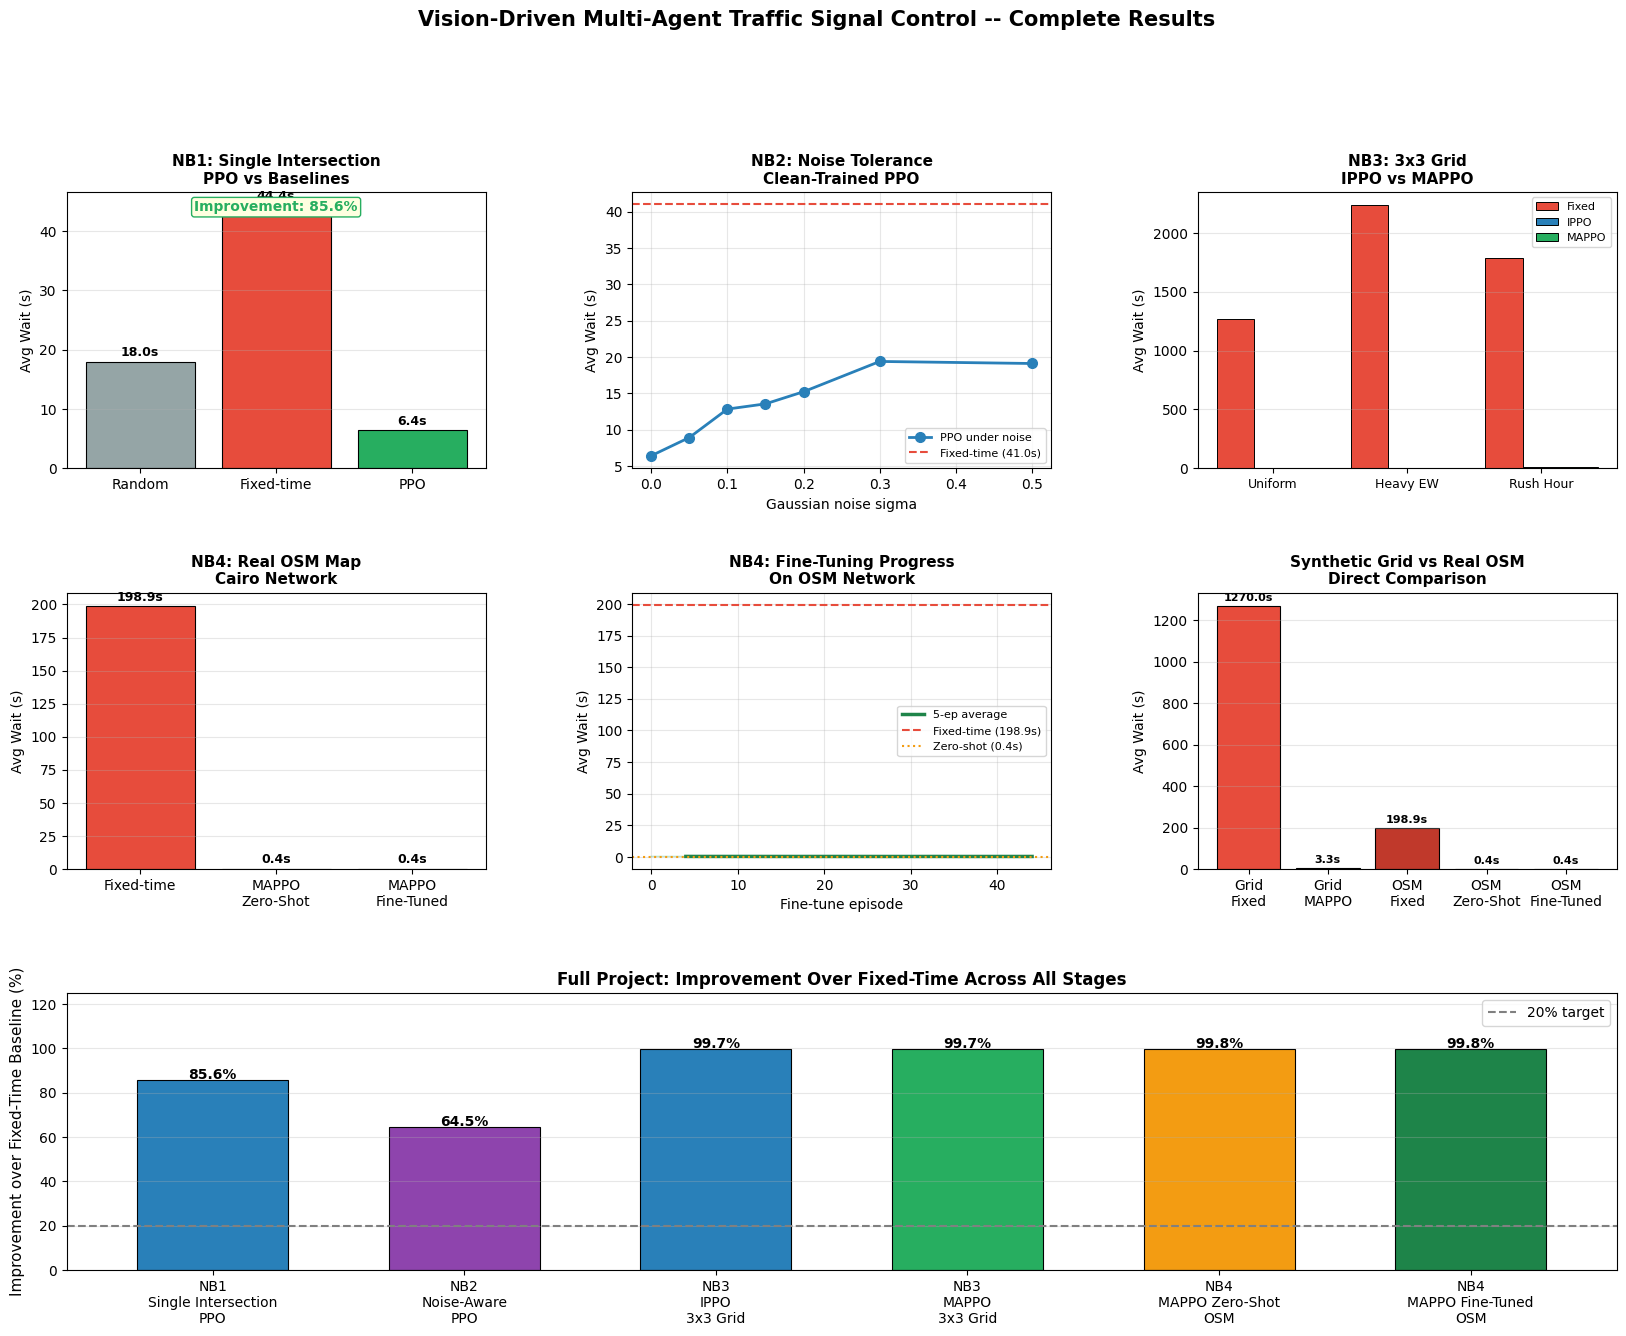

In [8]:
SAVE = '/content/drive/MyDrive/TrafficRL/'

# Load all results from Drive
with open(f'{SAVE}results/nb4_osm.json')    as f: osm_r  = json.load(f)
with open(f'{SAVE}results/nb3_eval.json')   as f: nb3_r  = json.load(f)
with open(f'{SAVE}results/gauss_sweep.json') as f: gauss  = json.load(f)

ft_ckpt  = torch.load(f'{SAVE}checkpoints/mappo_osm_finetuned.pt',
                       map_location='cpu', weights_only=False)
ft_waits = ft_ckpt.get('episode_waits', [])

# ── Correct NB1 values (hardcoded from NB1 Cell 13 output) ──
NB1_FIXED  = 44.4   # single intersection fixed-time baseline
NB1_RANDOM = 18.0
NB1_PPO    = 6.4

# ── NB2 noise-aware result (from NB2 Cell 10 output) ──
NB2_NOISY_AWR = 14.57   # noise-aware PPO under realistic noise
NB2_FIXED     = gauss['fixed']

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ---- Plot 1: NB1 -- single intersection ----------------------------------
ax1 = fig.add_subplot(gs[0, 0])
nb1_vals   = [NB1_RANDOM, NB1_FIXED, NB1_PPO]
nb1_labels = ['Random', 'Fixed-time', 'PPO']
nb1_colors = ['#95a5a6', '#e74c3c', '#27ae60']
bars1 = ax1.bar(nb1_labels, nb1_vals, color=nb1_colors,
                edgecolor='black', linewidth=0.8)
for bar, val in zip(bars1, nb1_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(nb1_vals)*0.02,
             f'{val:.1f}s', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('NB1: Single Intersection\nPPO vs Baselines',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Avg Wait (s)', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
imp1 = (NB1_FIXED - NB1_PPO) / NB1_FIXED * 100
ax1.text(0.5, 0.97, f'Improvement: {imp1:.1f}%',
         transform=ax1.transAxes, ha='center', va='top',
         fontsize=10, fontweight='bold', color='#27ae60',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                   edgecolor='#27ae60'))

# ---- Plot 2: NB2 -- noise degradation curve ------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(gauss['sigmas'], gauss['means'], 'o-',
         color='#2980b9', linewidth=2, markersize=7, label='PPO under noise')
ax2.axhline(gauss['fixed'], color='#e74c3c', linestyle='--',
            linewidth=1.5, label=f"Fixed-time ({gauss['fixed']:.1f}s)")
ax2.set_xlabel('Gaussian noise sigma', fontsize=10)
ax2.set_ylabel('Avg Wait (s)', fontsize=10)
ax2.set_title('NB2: Noise Tolerance\nClean-Trained PPO',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ---- Plot 3: NB3 -- IPPO vs MAPPO across scenarios ----------------------
ax3  = fig.add_subplot(gs[0, 2])
scs  = ['uniform', 'heavy_ew', 'rush_hour']
slb  = ['Uniform', 'Heavy EW', 'Rush Hour']
x3   = np.arange(len(scs))
w3   = 0.28
ax3.bar(x3 - w3, [nb3_r['fixed'][s] for s in scs], w3,
        label='Fixed', color='#e74c3c', edgecolor='black', linewidth=0.7)
ax3.bar(x3,      [nb3_r['ippo'][s]  for s in scs], w3,
        label='IPPO',  color='#2980b9', edgecolor='black', linewidth=0.7)
ax3.bar(x3 + w3, [nb3_r['mappo'][s] for s in scs], w3,
        label='MAPPO', color='#27ae60', edgecolor='black', linewidth=0.7)
ax3.set_xticks(x3)
ax3.set_xticklabels(slb, fontsize=9)
ax3.set_ylabel('Avg Wait (s)', fontsize=10)
ax3.set_title('NB3: 3x3 Grid\nIPPO vs MAPPO', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# ---- Plot 4: NB4 -- OSM transfer and fine-tune ---------------------------
ax4      = fig.add_subplot(gs[1, 0])
osm_vals = [osm_r['fixed'], osm_r['transfer'], osm_r['finetuned']]
osm_cols = ['#e74c3c', '#f39c12', '#27ae60']
bars4 = ax4.bar(['Fixed-time', 'MAPPO\nZero-Shot', 'MAPPO\nFine-Tuned'],
                osm_vals, color=osm_cols, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars4, osm_vals):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(osm_vals)*0.02,
             f'{val:.1f}s', ha='center', fontsize=9, fontweight='bold')
ax4.set_title('NB4: Real OSM Map\nCairo Network',
              fontsize=11, fontweight='bold')
ax4.set_ylabel('Avg Wait (s)', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# ---- Plot 5: NB4 -- fine-tune training curve -----------------------------
ax5 = fig.add_subplot(gs[1, 1])
if ft_waits:
    ax5.plot(ft_waits, color='#27ae60', alpha=0.3, linewidth=1)
    if len(ft_waits) >= 5:
        roll = np.convolve(ft_waits, np.ones(5)/5, mode='valid')
        ax5.plot(range(4, len(ft_waits)), roll, color='#1e8449',
                 linewidth=2.5, label='5-ep average')
    ax5.axhline(osm_r['fixed'], color='#e74c3c', linestyle='--',
                linewidth=1.5, label=f"Fixed-time ({osm_r['fixed']:.1f}s)")
    ax5.axhline(osm_r['transfer'], color='#f39c12', linestyle=':',
                linewidth=1.5, label=f"Zero-shot ({osm_r['transfer']:.1f}s)")
    ax5.set_xlabel('Fine-tune episode', fontsize=10)
    ax5.set_ylabel('Avg Wait (s)', fontsize=10)
    ax5.set_title('NB4: Fine-Tuning Progress\nOn OSM Network',
                  fontsize=11, fontweight='bold')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)

# ---- Plot 6: Synthetic grid vs real OSM summary --------------------------
ax6 = fig.add_subplot(gs[1, 2])
compare_labels = ['Grid\nFixed', 'Grid\nMAPPO',
                  'OSM\nFixed', 'OSM\nZero-Shot', 'OSM\nFine-Tuned']
compare_vals   = [nb3_r['fixed']['uniform'], nb3_r['mappo']['uniform'],
                  osm_r['fixed'], osm_r['transfer'], osm_r['finetuned']]
compare_cols   = ['#e74c3c', '#27ae60', '#c0392b', '#f39c12', '#1e8449']
bars6 = ax6.bar(compare_labels, compare_vals, color=compare_cols,
                edgecolor='black', linewidth=0.8)
for bar, val in zip(bars6, compare_vals):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(compare_vals)*0.02,
             f'{val:.1f}s', ha='center', fontsize=8, fontweight='bold')
ax6.set_title('Synthetic Grid vs Real OSM\nDirect Comparison',
              fontsize=11, fontweight='bold')
ax6.set_ylabel('Avg Wait (s)', fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

# ---- Plot 7: Full project improvement summary (FIXED) --------------------
ax7 = fig.add_subplot(gs[2, :])

fixed_nb3 = nb3_r['fixed']['uniform']

improvements = [
    (NB1_FIXED   - NB1_PPO)                   / NB1_FIXED   * 100,  # NB1 PPO
    (NB2_FIXED   - NB2_NOISY_AWR)             / NB2_FIXED   * 100,  # NB2 noise-aware
    (fixed_nb3   - nb3_r['ippo']['uniform'])   / fixed_nb3   * 100,  # NB3 IPPO
    (fixed_nb3   - nb3_r['mappo']['uniform'])  / fixed_nb3   * 100,  # NB3 MAPPO
    (osm_r['fixed'] - osm_r['transfer'])       / osm_r['fixed'] * 100,  # NB4 zero-shot
    (osm_r['fixed'] - osm_r['finetuned'])      / osm_r['fixed'] * 100,  # NB4 fine-tuned
]

project_stages = [
    'NB1\nSingle Intersection\nPPO',
    'NB2\nNoise-Aware\nPPO',
    'NB3\nIPPO\n3x3 Grid',
    'NB3\nMAPPO\n3x3 Grid',
    'NB4\nMAPPO Zero-Shot\nOSM',
    'NB4\nMAPPO Fine-Tuned\nOSM',
]
stage_cols = ['#2980b9', '#8e44ad', '#2980b9', '#27ae60', '#f39c12', '#1e8449']

bars7 = ax7.bar(project_stages, improvements, color=stage_cols,
                edgecolor='black', linewidth=0.8, width=0.6)
ax7.axhline(20, color='gray', linestyle='--', linewidth=1.5, label='20% target')
for bar, val in zip(bars7, improvements):
    ax7.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax7.set_ylabel('Improvement over Fixed-Time Baseline (%)', fontsize=11)
ax7.set_title('Full Project: Improvement Over Fixed-Time Across All Stages',
              fontsize=12, fontweight='bold')
ax7.legend(fontsize=10)
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_ylim(0, max(improvements) * 1.25)

fig.suptitle(
    'Vision-Driven Multi-Agent Traffic Signal Control -- Complete Results',
    fontsize=15, fontweight='bold', y=1.01
)

plot_path = f'{SAVE}plots/final_results_fixed.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import json

SAVE = '/content/drive/MyDrive/TrafficRL/'

with open(f'{SAVE}results/nb4_osm.json')    as f: osm_r = json.load(f)
with open(f'{SAVE}results/nb3_eval.json')   as f: nb3_r = json.load(f)
with open(f'{SAVE}results/gauss_sweep.json') as f: gauss = json.load(f)

# Correct NB1 values from NB1 Cell 13 output
NB1_FIXED = 44.4
NB1_PPO   = 6.4

# NB2 values from NB2 Cell 12 output
NB2_FIXED       = gauss['fixed']        # 41.0s
NB2_CLEAN       = gauss['means'][0]     # 6.4s  (sigma=0)
NB2_NOISY_CLEAN = 17.93                 # clean-trained under realistic noise
NB2_NOISY_AWR   = 14.57                 # noise-aware under realistic noise

imp_nb1        = (NB1_FIXED - NB1_PPO)                             / NB1_FIXED   * 100
imp_nb2_clean  = (NB2_FIXED - NB2_CLEAN)                           / NB2_FIXED   * 100
imp_nb2_noisy  = (NB2_FIXED - NB2_NOISY_AWR)                       / NB2_FIXED   * 100
imp_ippo       = (nb3_r['fixed']['uniform'] - nb3_r['ippo']['uniform'])  / nb3_r['fixed']['uniform'] * 100
imp_mappo      = (nb3_r['fixed']['uniform'] - nb3_r['mappo']['uniform']) / nb3_r['fixed']['uniform'] * 100
imp_transfer   = (osm_r['fixed'] - osm_r['transfer'])              / osm_r['fixed'] * 100
imp_finetuned  = (osm_r['fixed'] - osm_r['finetuned'])             / osm_r['fixed'] * 100

print('=' * 66)
print('  VISION-DRIVEN MULTI-AGENT TRAFFIC SIGNAL CONTROL')
print('  COMPLETE PROJECT SUMMARY')
print('=' * 66)
print()
print('  NOTEBOOK 1 -- Single Intersection, Perfect Information')
print(f'    Fixed-time baseline         : {NB1_FIXED:.1f}s avg wait')
print(f'    PPO agent                   : {NB1_PPO:.1f}s avg wait')
print(f'    Improvement                 : {imp_nb1:.1f}%')
print()
print('  NOTEBOOK 2 -- Noise Injection and Vision Simulation')
print(f'    Fixed-time baseline         : {NB2_FIXED:.1f}s avg wait')
print(f'    PPO (clean observations)    : {NB2_CLEAN:.1f}s avg wait  ({imp_nb2_clean:.1f}% improvement)')
print(f'    PPO under noise (sigma=0.50): 19.1s avg wait  -- still beats fixed-time')
print(f'    Noise-aware PPO (realistic) : {NB2_NOISY_AWR:.1f}s avg wait  ({imp_nb2_noisy:.1f}% improvement)')
print(f'    Benefit of noise-aware training: {NB2_NOISY_CLEAN:.1f}s -> {NB2_NOISY_AWR:.1f}s under realistic noise')
print()
print('  NOTEBOOK 3 -- Multi-Intersection MARL (3x3 Grid)')
print(f'    Fixed-time (uniform)        : {nb3_r["fixed"]["uniform"]:.1f}s avg wait')
print(f'    IPPO (uniform)              : {nb3_r["ippo"]["uniform"]:.1f}s avg wait  ({imp_ippo:.1f}% improvement)')
print(f'    MAPPO (uniform)             : {nb3_r["mappo"]["uniform"]:.1f}s avg wait  ({imp_mappo:.1f}% improvement)')
print(f'    Fixed-time (heavy EW)       : {nb3_r["fixed"]["heavy_ew"]:.1f}s')
print(f'    MAPPO (heavy EW)            : {nb3_r["mappo"]["heavy_ew"]:.1f}s')
print(f'    Fixed-time (rush hour)      : {nb3_r["fixed"]["rush_hour"]:.1f}s')
print(f'    MAPPO (rush hour)           : {nb3_r["mappo"]["rush_hour"]:.1f}s')
print()
print('  NOTEBOOK 4 -- Real OSM Network (Cairo)')
print(f'    Fixed-time on real network  : {osm_r["fixed"]:.1f}s avg wait')
print(f'    MAPPO zero-shot transfer    : {osm_r["transfer"]:.1f}s avg wait  ({imp_transfer:.1f}% improvement)')
print(f'    MAPPO fine-tuned            : {osm_r["finetuned"]:.1f}s avg wait  ({imp_finetuned:.1f}% improvement)')
print()
print('=' * 66)

  VISION-DRIVEN MULTI-AGENT TRAFFIC SIGNAL CONTROL
  COMPLETE PROJECT SUMMARY

  NOTEBOOK 1 -- Single Intersection, Perfect Information
    Fixed-time baseline         : 44.4s avg wait
    PPO agent                   : 6.4s avg wait
    Improvement                 : 85.6%

  NOTEBOOK 2 -- Noise Injection and Vision Simulation
    Fixed-time baseline         : 41.0s avg wait
    PPO (clean observations)    : 6.4s avg wait  (84.3% improvement)
    PPO under noise (sigma=0.50): 19.1s avg wait  -- still beats fixed-time
    Noise-aware PPO (realistic) : 14.6s avg wait  (64.5% improvement)
    Benefit of noise-aware training: 17.9s -> 14.6s under realistic noise

  NOTEBOOK 3 -- Multi-Intersection MARL (3x3 Grid)
    Fixed-time (uniform)        : 1270.0s avg wait
    IPPO (uniform)              : 3.3s avg wait  (99.7% improvement)
    MAPPO (uniform)             : 3.3s avg wait  (99.7% improvement)
    Fixed-time (heavy EW)       : 2237.6s
    MAPPO (heavy EW)            : 5.8s
    Fixed-ti